# **Importing Necessary Libraries**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from IPython.display import display

## Mounting the Drive

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Loading the tables

In [3]:
# List contents of the mounted Google Drive
print("Contents of your Google Drive:")
drive_path = '/content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/datasets'
df_names = []

if os.path.exists(drive_path):
    for item in os.listdir(drive_path):
        if item.endswith('.csv'):
            file_path = os.path.join(drive_path, item)
            df_name = item.replace('.csv', '').replace('dim_', 'df_').replace('fact_', 'df_')
            globals()[df_name] = pd.read_csv(file_path)
            df_names.append(df_name)
            print(f"Loaded {item} as DataFrame: {df_name}")
else:
    print(f"Drive not mounted at {drive_path}. Please ensure drive.mount('/content/drive') was executed successfully.")

Contents of your Google Drive:
Loaded fact_aggregated_bookings.csv as DataFrame: df_aggregated_bookings
Loaded dim_hotels.csv as DataFrame: df_hotels
Loaded new_data_august.csv as DataFrame: new_data_august
Loaded dim_rooms.csv as DataFrame: df_rooms
Loaded fact_bookings.csv as DataFrame: df_bookings
Loaded dim_date.csv as DataFrame: df_date


# **Problem Statement**

**The Situation:** Atliq Grands, a hotel chain with a diverse portfolio of luxury and business properties, operates across major Indian cities (Delhi, Mumbai, Bangalore, Hyderabad).

**The Complication:** However, Atliq Grands is currently facing a significant decline in revenue and market share, specifically struggling with low occupancy rates and discrepancies between expected and realized revenue.

**The Objective:** Therefore, the primary goal of this Exploratory Data Analysis (EDA) is to *analyze historical booking and property data to uncover underlying patterns, identify the root causes of this decline, and deliver actionable recommendations to optimize pricing, improve occupancy, and regain market share.*

# **Data Understanding**

In [4]:
df_names

['df_aggregated_bookings',
 'df_hotels',
 'new_data_august',
 'df_rooms',
 'df_bookings',
 'df_date']

In [5]:
for df_name in df_names:
  df = globals().get(df_name)
  print(f"DataFrame Name: {df_name}")
  display(df.head())
  print('\n')

DataFrame Name: df_aggregated_bookings


,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,1-May-22,RT1,25,30.0
1,19562,1-May-22,RT1,28,30.0
2,19563,1-May-22,RT1,23,30.0
3,17558,1-May-22,RT1,30,19.0
4,16558,1-May-22,RT1,18,19.0




DataFrame Name: df_hotels


,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi




DataFrame Name: new_data_august


...

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential




DataFrame Name: df_bookings


,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,1/5/2022,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920




DataFrame Name: df_date


,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


**df_rooms:** A dimension table defining the specific room classes available
across Atliq properties, such as Standard, Elite, Premium, and Presidential.

**df_bookings:** A granular fact table recording individual customer transactions, including the booking platform used, check-in dates, revenue realized, and the final booking status (e.g., Cancelled or Checked Out).

**df_date:** A dimension table mapping specific check-in dates to month, week numbers, and day types (weekday vs. weekend), which will be crucial for analyzing booking seasonality.

**df_hotels:** A dimension table detailing property-specific information, including the hotel's name, its city location, and its target category (Business or Luxury).

**df_aggregated_bookings:** A summary fact table showing daily aggregated metrics at the property and room-category level, specifically tracking the total successful bookings against the total room capacity (inventory).

**new_data_august:** A denormalized file containing newly arrived records for August. It combines both property dimensions and booking facts (including pre-calculated occupancy percentages) into a single table.

# **Data Profiling**

Proper data profiling is like a health checkup for our dataset. Before we draw any business conclusions, we need to know exactly what we are working with. A solid profiling workflow in pandas covers three main areas:

**Shape and Structure:** What it is: Checking the total number of rows and columns,
and verifying that each column has the correct data type.

**Completeness and Quality:** What it is: Identifying missing values (Nulls/NaNs), finding duplicate rows, and spotting obvious garbage data.

**Distributions and Frequencies:** What it is: Calculating the categorical value counts.

In [6]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  object 
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  object 
 3   check_in_date      134590 non-null  object 
 4   checkout_date      134590 non-null  object 
 5   no_guests          134587 non-null  float64
 6   room_category      134590 non-null  object 
 7   booking_platform   134590 non-null  object 
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  object 
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 12.3+ MB


In [7]:
df_bookings.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [8]:
columns = ['booking_platform', 'booking_status', 'room_category']

for column in columns:
  print(f'The counts of {column}')
  display(df_bookings[column].value_counts())
  print('\n')

The counts of booking_platform


,count
booking_platform,
others,55066
makeyourtrip,26898
logtrip,14756
direct online,13379
tripster,9630
journey,8106
direct offline,6755




The counts of booking_status


,count
booking_status,
Checked Out,94411
Cancelled,33420
No Show,6759




The counts of room_category


,count
room_category,
RT2,49505
RT1,38446
RT3,30566
RT4,16073


In [9]:
def check_unique_values(df, column_name):
    unique_values = df[column_name].unique()
    total_values = len(df[column_name])
    print(f"Number of unique values: {len(unique_values)}")
    print(f"Total values: {total_values}")

    if len(unique_values) == total_values:
        print(f"All {column_name} values are unique.")
    else:
        print("There are duplicate values.")

check_unique_values(df_hotels, 'property_id')
check_unique_values(df_rooms, 'room_id')

Number of unique values: 25
Total values: 25
All property_id values are unique.
Number of unique values: 4
Total values: 4
All room_id values are unique.


In [10]:
display(df_hotels.city.value_counts())
display(df_hotels.category.value_counts())

,count
city,
Mumbai,8
Hyderabad,6
Bangalore,6
Delhi,5


,count
category,
Luxury,16
Business,9


In [11]:
new_columns = new_data_august.columns
prior_columns = df_bookings.columns

common_columns = list(set(new_columns) & set(prior_columns))
print("\nColumns common to both new_data_august and df_bookings:", common_columns, sep = "\n")

new_only_columns = list(set(new_columns) - set(prior_columns))
print("\nColumns in new_data_august but not in df_bookings:", new_only_columns, sep = "\n")

prior_only_columns = list(set(prior_columns) - set(new_columns))
print("\nColumns in df_bookings but not in new_data_august:", prior_only_columns, sep = "\n")


Columns common to both new_data_august and df_bookings:
['property_id', 'check_in_date', 'room_category']

Columns in new_data_august but not in df_bookings:
['property_name', 'day_type', 'category', 'mmm yy', 'successful_bookings', 'room_class', 'capacity', 'occ%', 'week no', 'city']

Columns in df_bookings but not in new_data_august:
['booking_id', 'checkout_date', 'revenue_generated', 'ratings_given', 'booking_date', 'booking_platform', 'booking_status', 'revenue_realized', 'no_guests']


In [12]:
new_data_august.columns

Index(['property_id', 'property_name', 'category', 'city', 'room_category',
       'room_class', 'check_in_date', 'mmm yy', 'week no', 'day_type',
       'successful_bookings', 'capacity', 'occ%'],
      dtype='object')

## Profiling Conclusion:

Initial data profiling reveals perfect integrity across our dimension tables, confirming a portfolio of 25 properties (primarily Luxury establishments centered in Mumbai) and 4 room classes. However, the main **df_bookings** transaction table (134,590 entries) requires significant remediation to address missing values, incorrect text-based date formats, and critical statistical anomalies like impossible negative guest counts and a massive 28-million revenue outlier. Despite these data quality issues, initial distributions highlight a heavy reliance on third-party booking platforms, a preference for 'RT2' rooms, and a severe ~25% cancellation rate directly driving Atliq's revenue leakage. Finally, the newly provided August dataset must be handled separately or joined on different keys, as its pre-aggregated format cannot be directly appended to our granular historical transactions.

# **Data Cleaning**

To remove the anomalies, we will use a concept called "boolean masking" in pandas to filter our dataframe.

### 1. Handling negative guest values

For the guest counts, it's a simple greater-than-zero rule.

In [13]:
df_bookings = df_bookings[df_bookings['no_guests'] > 0]

### 2. Handling revenue outliers

For the revenue outlier, we can apply the 3-Sigma Rule (3 Standard Deviations). This statistical technique calculates the average revenue, measures how spread out the data is, and establishes an upper limit. Anything beyond that limit is considered an unrealistic outlier and is removed.

In [14]:
mean_rev = df_bookings.revenue_generated.mean()
std_rev = df_bookings.revenue_generated.std()
upper_limit = mean_rev + 3 * std_rev

df_bookings = df_bookings[df_bookings.revenue_generated <= upper_limit]

### 3. Standardizing datetime

In [15]:
date_columns = ['booking_date', 'check_in_date', 'checkout_date']

for column in date_columns:
  df_bookings[column] = pd.to_datetime(df_bookings[column], dayfirst= True, format = 'mixed')

print(df_bookings[date_columns].dtypes)

booking_date     datetime64[ns]
check_in_date    datetime64[ns]
checkout_date    datetime64[ns]
dtype: object


In [16]:
df_date['date'] = pd.to_datetime(df_date['date'], dayfirst= True, format = 'mixed')

In [17]:
new_data_august['check_in_date'] = pd.to_datetime(new_data_august['check_in_date'], dayfirst= True, format = 'mixed')

In [72]:
df_aggregated_bookings['check_in_date'] = pd.to_datetime(df_aggregated_bookings['check_in_date'], dayfirst= True, format = 'mixed')

In [18]:
print(df_bookings[date_columns].isnull().sum())

booking_date     0
check_in_date    0
checkout_date    0
dtype: int64


### 4. Handling missing values (Imputation)

**no_guests:** Since only 3 rows are missing out of over 134,000, we could safely drop them. However, a standard data science practice for numerical columns with minimal missing data is to fill them with the median value. This preserves the revenue data attached to those rows without skewing our average guest count.

In [19]:
median_guests = df_bookings.no_guests.median()
df_bookings.no_guests.fillna(median_guests, inplace = True)

/tmp/ipykernel_79207/3315412987.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bookings.no_guests.fillna(median_guests, inplace = True)


In [20]:
df_bookings.ratings_given.isnull().sum()

np.int64(77897)

In [21]:
df_bookings.groupby('booking_status')['ratings_given'].apply(lambda x: x.isnull().sum())

,ratings_given
booking_status,
Cancelled,33416
Checked Out,37723
No Show,6758


Missing values in the **ratings** column must intentionally remain as Null (NaN). Over 40,000 missing entries belong to cancelled or no-show bookings where no stay occurred. For the remaining 33,000 missing ratings from checked-out guests, this simply reflects normal behavior where patrons opt out of post-stay surveys. Imputing these blanks with a mean or median score would inject tens of thousands of artificial *"average"* opinions, shrinking the dataset's variance and severely distorting the true measurement of Atliq's hotel performance.

# **Data Transformation**

To effectively analyze the "where" and "why" behind the revenue drop, we must transform our transactional data into a rich, unified dataset. Here are the required transformations:

### 1. Data Integration (Table Merging)

We currently have a star schema structure . To perform slice-and-dice analysis, we need to bring all the contextual dimensions into our central fact table using pandas merges:

In [22]:
# Merging Hotels
df_merged = pd.merge(df_bookings, df_hotels, on = 'property_id', how = 'left')

# Merging Rooms
df_merged = pd.merge(df_merged, df_rooms, left_on = 'room_category', right_on = 'room_id')

# Merging Dates
df_merged = pd.merge(df_merged, df_date, left_on = 'check_in_date', right_on = 'date')

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134573 entries, 0 to 134572
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   booking_id         134573 non-null  object        
 1   property_id        134573 non-null  int64         
 2   booking_date       134573 non-null  datetime64[ns]
 3   check_in_date      134573 non-null  datetime64[ns]
 4   checkout_date      134573 non-null  datetime64[ns]
 5   no_guests          134573 non-null  float64       
 6   room_category      134573 non-null  object        
 7   booking_platform   134573 non-null  object        
 8   ratings_given      56676 non-null   float64       
 9   booking_status     134573 non-null  object        
 10  revenue_generated  134573 non-null  int64         
 11  revenue_realized   134573 non-null  int64         
 12  property_name      134573 non-null  object        
 13  category           134573 non-null  object  

### Appending the August data

In [23]:
df_merged = pd.concat([df_merged, new_data_august], ignore_index= True, axis = 0)
df_merged.tail(12)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,...,city,room_id,room_class,date,mmm yy,week no,day_type,successful_bookings,capacity,occ%
134568,Jul312217564RT45,17564,2022-07-30,2022-07-31,2022-08-01,2.0,RT4,others,2.0,Checked Out,...,Mumbai,RT4,Presidential,2022-07-31,Jul 22,W 32,weekend,NaN,NaN,NaN
134569,Jul312217564RT46,17564,2022-07-29,2022-07-31,2022-08-03,1.0,RT4,makeyourtrip,2.0,Checked Out,...,Mumbai,RT4,Presidential,2022-07-31,Jul 22,W 32,weekend,NaN,NaN,NaN
134570,Jul312217564RT48,17564,2022-07-30,2022-07-31,2022-08-02,1.0,RT4,tripster,NaN,Cancelled,...,Mumbai,RT4,Presidential,2022-07-31,Jul 22,W 32,weekend,NaN,NaN,NaN
134571,Jul312217564RT49,17564,2022-07-29,2022-07-31,2022-08-01,2.0,RT4,logtrip,2.0,Checked Out,...,Mumbai,RT4,Presidential,2022-07-31,Jul 22,W 32,weekend,NaN,NaN,NaN
134572,Jul312217564RT410,17564,2022-07-31,2022-07-31,2022-08-01,2.0,RT4,makeyourtrip,NaN,Cancelled,...,Mumbai,RT4,Presidential,2022-07-31,Jul 22,W 32,weekend,NaN,NaN,NaN
134573,NaN,16559,NaT,2022-08-01,NaT,NaN,RT1,NaN,NaN,NaN,...,Mumbai,NaN,Standard,NaT,Aug-22,W 32,weekeday,30.0,30.0,100.00
134574,NaN,19562,NaT,2022-08-01,NaT,NaN,RT1,NaN,NaN,NaN,...,Bangalore,NaN,Standard,NaT,Aug-22,W 32,weekeday,21.0,30.0,70.00
134575,NaN,19563,NaT,2022-08-01,NaT,NaN,RT1,NaN,NaN,NaN,...,Bangalore,NaN,Standard,NaT,Aug-22,W 32,weekeday,23.0,30.0,76.67
134576,NaN,19558,NaT,2022-08-01,NaT,NaN,RT1,NaN,NaN,NaN,...,Bangalore,NaN,Standard,NaT,Aug-22,W 32,weekeday,30.0,40.0,75.00
134577,NaN,19560,NaT,2022-08-01,NaT,NaN,RT1,NaN,NaN,NaN,...,Bangalore,NaN,Standard,NaT,Aug-22,W 32,weekeday,20.0,26.0,76.92


### 2. Feature Engineering (Creating New Metrics)
We need to derive new columns from our existing data that specifically measure hospitality performance.


**Assumptions and Limitations:**

**Domain Assumption (Lead Time):** We assume a standard hospitality booking window where the booking_date always precedes or equals the check_in_date. Any negative lead time indicates a data entry error.

**Domain Assumption (Length of Stay):** We assume all valid reservations have a minimum Length of Stay (LOS) of 1 day (overnight).

**Data Limitation:** Because our dates were originally mixed-format text, calculating differences might expose lingering illogical dates (e.g., check-out dates occurring before check-in dates) that we will need to filter out.

**a. Revenue Leakage (Financial):** The mathematical difference between expected revenue (revenue_generated) and actual collected cash (revenue_realized). This isolates the exact cost of every cancellation and no-show, allowing us to see which city or platform is bleeding the most money.

In [24]:
df_merged['revenue_leakage'] = df_merged['revenue_generated'] - df_merged['revenue_realized']

**b. Booking Lead Time (Behavioral):** The number of days between when a guest books and when they check in. A shrinking lead time often means a hotel is heavily relying on less profitable, last-minute bookings.

In [25]:
df_merged['booking_lead_time'] = (df_merged['check_in_date'] - df_merged['booking_date']).dt.days

In [26]:
print('Negative Lead time count:', (df_merged['booking_lead_time'] < 0).sum())

Negative Lead time count: 0


**c. Length of Stay / LOS (Behavioral):** The total nights a guest stays. Drops in average LOS can heavily depress occupancy rates even if the total number of check-ins remains steady.

In [27]:
df_merged['length_of_stay'] = (df_merged['checkout_date'] - df_merged['check_in_date']).dt.days

In [28]:
print('Negative LOS count:', (df_merged['length_of_stay'] < 0).sum())

Negative LOS count: 0


**d. Occupancy Percentage:** While we can look at absolute numbers of bookings, Occupancy Percentage is the true heartbeat of hotel performance. It tells us exactly how efficiently we are filling our available rooms.

The mathematical formula is straightforward:
*(Successful Bookings ÷ Total Capacity) × 100*

In [29]:
df_aggregated_bookings['occ_pct'] = ((df_aggregated_bookings['successful_bookings'] / df_aggregated_bookings['capacity']) * 100).round(2)

In [30]:
df_aggregated_bookings['occ_pct'].describe()

,occ_pct
count,9198.000000
mean,58.398338
std,16.064498
min,21.050000
25%,47.370000
50%,56.250000
75%,66.670000
max,473.080000


In [31]:
df_aggregated_bookings[df_aggregated_bookings['occ_pct'] > 100.00]

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
3,17558,1-May-22,RT1,30,19.0,157.89
12,16563,1-May-22,RT1,100,41.0,243.90
4136,19558,11-Jun-22,RT2,50,39.0,128.21
6209,19560,2-Jul-22,RT1,123,26.0,473.08
8522,19559,25-Jul-22,RT1,35,24.0,145.83
9194,18563,31-Jul-22,RT4,20,18.0,111.11


In the hotel industry, a slight overbooking strategy (e.g., 105% to 115%) is common. Hotels do this deliberately to offset expected cancellations and no-shows, which is why your row showing 111.11% (20 bookings for 18 rooms) is actually plausible.

However, numbers like 473.08% (123 bookings for a 26-room capacity) or 243.90% are physically impossible. These are severe data entry errors in the successful_bookings column.


### Measures taken:

**Drop all 6 anomalous rows:** Because there are only 6 erroneous rows out of thousands of records, attempting to guess the "correct" number of bookings for them is not worth the risk. The safest, most statistically sound approach is to remove them entirely so they do not artificially inflate our chain-wide occupancy averages.

In [32]:
df_aggregated_bookings = df_aggregated_bookings[df_aggregated_bookings['occ_pct'] <= 100.00]

In [33]:
print('New maximum occupancy:', df_aggregated_bookings['occ_pct'].max())
print('New dataframe shape:', df_aggregated_bookings.shape)

New maximum occupancy: 100.0
New dataframe shape: (9192, 6)


# **Insight Generation**

To effectively solve Atliq's business problem, we must structure our EDA like a funnel—starting with high-level macro trends and drilling down into specific operational behaviors, into our 4-phase plan.

In [34]:
# Function to save plots

def saving_plots(fig, file_name):
  file_name = file_name + ".png"
  file_path = f"/content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/{file_name}"

  # Saving the figure. The 'fig' object should be accessible from the previous plotting cell.
  if 'fig' in globals():
    fig.savefig(file_path, bbox_inches='tight', dpi=300)
    print(f"Plots saved successfully to: {file_path}")
  else:
    print("Error: Figure object 'fig' not found. Please ensure the plotting cell (dtKphNBMK4oZ) has been executed recently and 'fig' is still in scope, or regenerate the plots.")

### **Phase 1: Macro-Level Performance**

To get a crystal-clear picture of the "What" and "Where," we need to aggregate our core metrics—Occupancy and Revenue—by city and hotel category (Business vs. Luxury).

Since our occupancy data lives in df_agg_bookings and our exact revenue data lives in df_merged, we will perform the calculations on their respective tables and then join the results together into one clean executive summary.

In [73]:
# Merge hotels dimension to our aggregated bookings to get 'city' and 'category'
df_agg_merged = pd.merge(df_aggregated_bookings, df_hotels, on = 'property_id', how = 'left')

In [36]:
# Calculate true Occupancy % by City and Category
occupancy_stats = df_agg_merged.groupby(['city', 'category']).agg(
    total_successful_bookings = ('successful_bookings', 'sum'),
    total_capacity = ('capacity', 'sum'),
).reset_index()

occupancy_stats['occupancy_pct'] = (occupancy_stats['total_successful_bookings'] / occupancy_stats['total_capacity'] * 100).round(2)

In [37]:
# Calculate Total Revenue Realized by city and category using our merged individual bookings table
revenue_stats = df_merged.groupby(['city', 'category']).agg(
    total_revenue_realized = ('revenue_realized', 'sum')
).reset_index()

In [38]:
# Combining both metrics into one final reporting table
phase_1_report = pd.merge(occupancy_stats, revenue_stats, on = ['city', 'category'], how = 'left')

# Formatting revenue for easier reading (in Millions)
phase_1_report['revenue_millions'] = (phase_1_report['total_revenue_realized'] / 1000000).round(2)

# Sort by Revenue to see our top performers instantly
phase_1_report = phase_1_report.sort_values(by='revenue_millions', ascending=False)

### Visualizing Phase 1 report

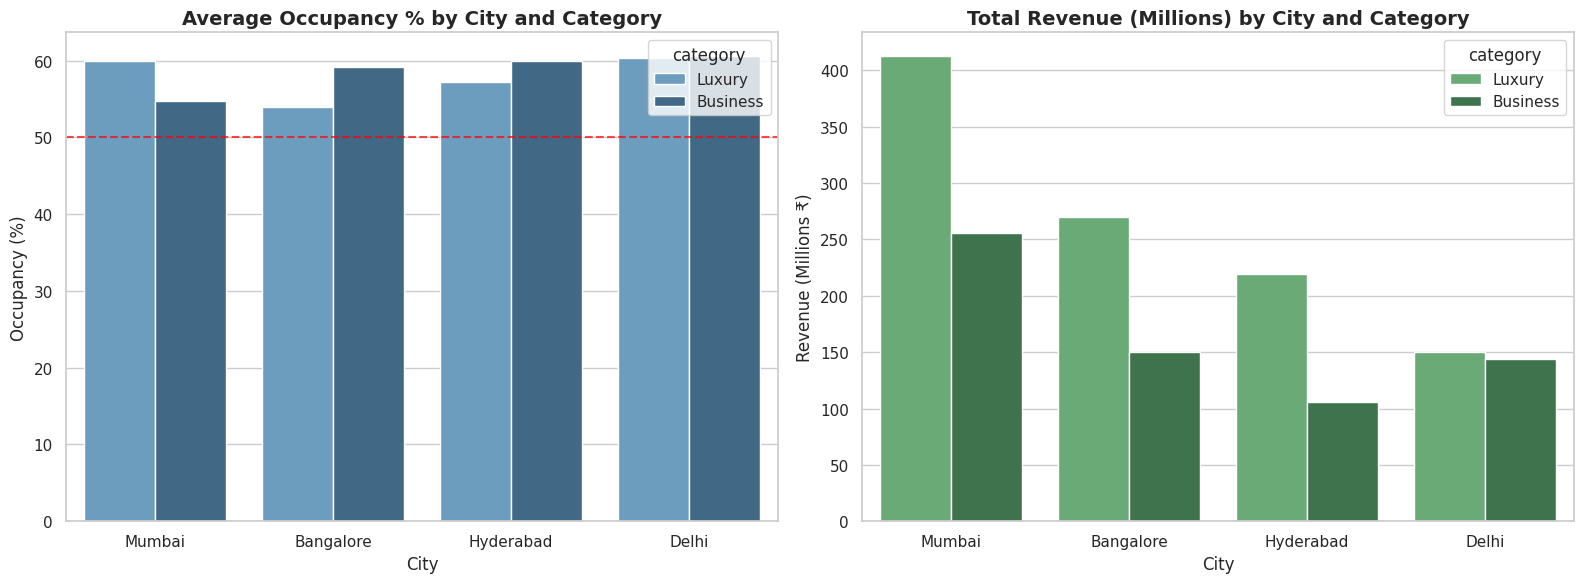

In [39]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Occupancy Percentage ---
sns.barplot(
    data=phase_1_report,
    x='city',
    y='occupancy_pct',
    hue='category',
    ax=axes[0],
    palette='Blues_d'
)
axes[0].set_title('Average Occupancy % by City and Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('City', fontsize=12)
axes[0].set_ylabel('Occupancy (%)', fontsize=12)
axes[0].axhline(50, color='red', linestyle='--', alpha=0.7) # Adding a baseline at 50%

# --- Chart 2: Total Revenue ---
sns.barplot(
    data=phase_1_report,
    x='city',
    y='revenue_millions',
    hue='category',
    ax=axes[1],
    palette='Greens_d'
)
axes[1].set_title('Total Revenue (Millions) by City and Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('City', fontsize=12)
axes[1].set_ylabel('Revenue (Millions ₹)', fontsize=12)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [40]:
saving_plots(fig, 'phase_1_report')

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_1_report.png


### Phase 1 conclusion:

Mumbai is Atliq's undisputed "cash cow," driven heavily by its Luxury segment which alone generates over 400 million in revenue. Interestingly, while occupancy remains healthy (above the 50% baseline) across all markets, higher occupancy in Business hotels—like we see in Bangalore and Hyderabad—doesn't translate to higher revenue. The Luxury tier consistently drives the lion's share of income across the board, with Delhi being the only city where revenue is evenly split between the two categories.

### **Phase 2: Booking Channel Efficiency**

Let's dive into the "Who"—the booking platforms driving our traffic. High volume from a specific platform is useless if most of those bookings end up cancelled. We need to measure the Cancellation Rate alongside the actual Revenue Leakage (the money left on the table) for each channel.

In [41]:
# Create a quick numeric flag for cancelled bookings to make summing easier
df_merged['is_cancelled'] = df_merged['booking_status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

# Group by platform to calculate our core channel metrics
platform_stats = df_merged.groupby('booking_platform').agg(
    total_bookings = ('booking_id', 'count'),
    cancelled_bookings = ('is_cancelled', 'sum'),
    revenue_realized = ('revenue_realized', 'sum'),
    revenue_leakage = ('revenue_leakage', 'sum')
).reset_index()

# Calculate the Cancellation Rate percentage and format revenue to Millions
platform_stats['cancellation_rate_pct'] = (platform_stats['cancelled_bookings'] / platform_stats['total_bookings'] * 100).round(2)
platform_stats['revenue_realized_millions'] = (platform_stats['revenue_realized'] / 1000000).round(2)
platform_stats['revenue_leakage_millions'] = (platform_stats['revenue_leakage'] / 1000000).round(2)

# Sort by revenue leakage to instantly see our biggest bleeders at the top
platform_stats = platform_stats.sort_values(by='revenue_leakage_millions', ascending=False)

In [42]:
display(platform_stats[['booking_platform', 'cancellation_rate_pct', 'revenue_realized_millions', 'revenue_leakage_millions']])

,booking_platform,cancellation_rate_pct,revenue_realized_millions,revenue_leakage_millions
5,others,24.87,699.31,121.70
4,makeyourtrip,24.99,340.81,60.66
3,logtrip,24.31,187.49,31.92
1,direct online,25.00,168.95,29.73
6,tripster,24.99,123.07,21.65
2,journey,24.78,102.53,18.12
0,direct offline,24.49,86.37,14.95


### Visualizing the Channel Bleed

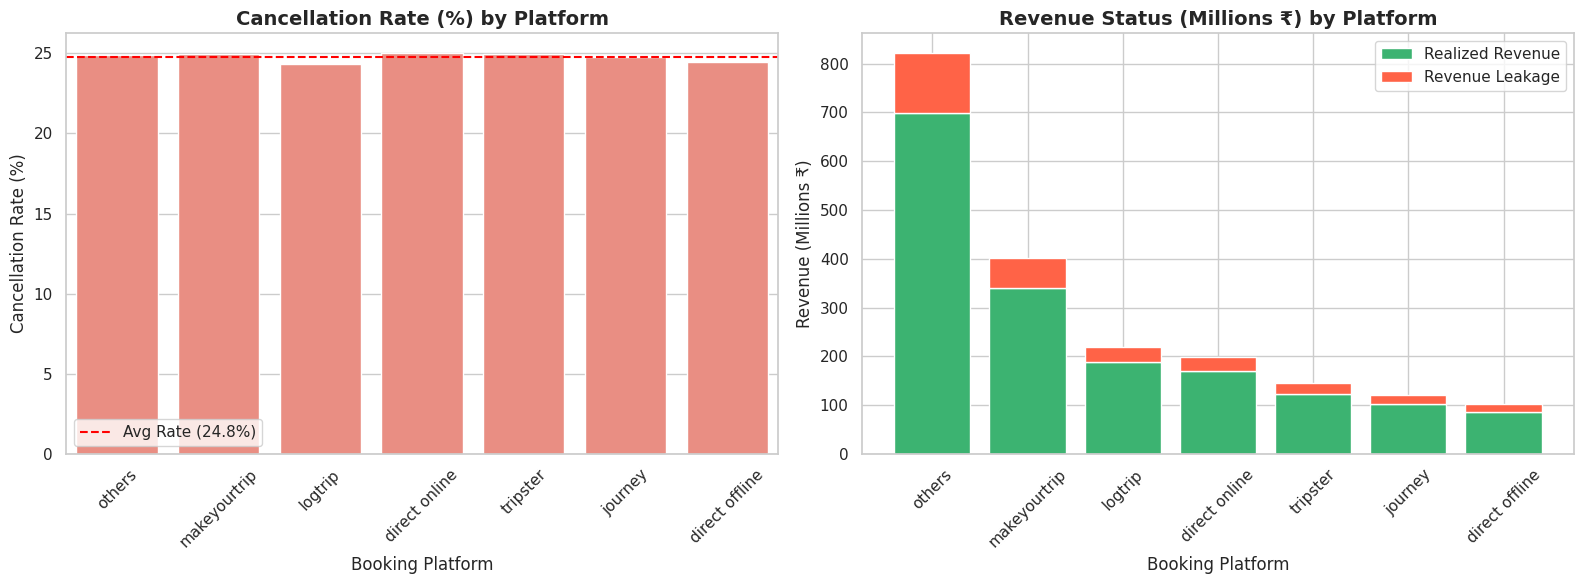

In [43]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Chart 1: Cancellation Rate by Platform ---
sns.barplot(
    data=platform_stats,
    x='booking_platform',
    y='cancellation_rate_pct',
    ax=axes[0],
    color='salmon'
)
axes[0].set_title('Cancellation Rate (%) by Platform', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Booking Platform', fontsize=12)
axes[0].set_ylabel('Cancellation Rate (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Add a baseline for the average cancellation rate across the chain
avg_cancel_rate = platform_stats['cancellation_rate_pct'].mean()
axes[0].axhline(avg_cancel_rate, color='red', linestyle='--', label=f'Avg Rate ({avg_cancel_rate:.1f}%)')
axes[0].legend()

# --- Chart 2: Revenue Realized vs. Leakage (Stacked) ---
# Plot Realized Revenue (The money we kept)
axes[1].bar(
    platform_stats['booking_platform'],
    platform_stats['revenue_realized_millions'],
    label='Realized Revenue',
    color='mediumseagreen'
)
# Plot Revenue Leakage on top (The money we lost)
axes[1].bar(
    platform_stats['booking_platform'],
    platform_stats['revenue_leakage_millions'],
    bottom=platform_stats['revenue_realized_millions'],
    label='Revenue Leakage',
    color='tomato'
)

axes[1].set_title('Revenue Status (Millions ₹) by Platform', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Booking Platform', fontsize=12)
axes[1].set_ylabel('Revenue (Millions ₹)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
saving_plots(fig, "phase_2_report")

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_2_report.png


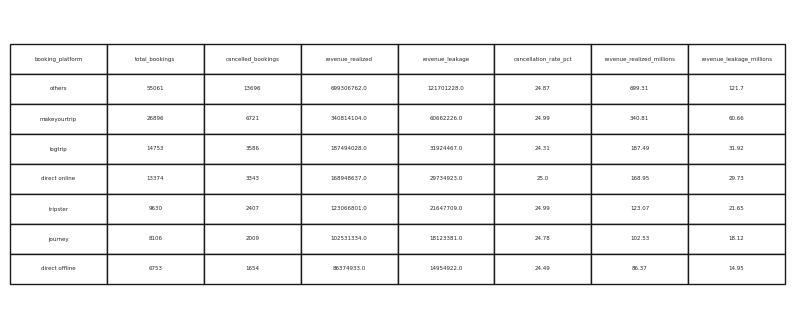

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

# Hide the standard graph axes
ax.axis('tight')
ax.axis('off')

# Draw the table on the blank figure
table = ax.table(
    cellText=platform_stats.values,
    colLabels=platform_stats.columns,
    loc='center',
    cellLoc='center'
)

# Make the rows a little taller for readability
table.scale(1, 1.8)

In [46]:
saving_plots(fig, "phase_2_table")

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_2_table.png


### Phase 2 conclusion:

The most striking takeaway is that the cancellation rate is shockingly uniform across every single platform, hovering tightly around the 24.8% average. Because guest cancellation behavior is practically identical everywhere, the massive revenue leakage from channels like 'others' (121.7M) and 'makeyourtrip' (60.66M) is purely a side effect of their high booking volume, not because they are "low-quality" channels. This points to a systemic, chain-wide issue with Atliq's reservation policies—such as a lack of non-refundable deposits—rather than a problem with any specific third-party partner.

### **Phase 3: Time-Based & Behavioral Trends**

Now we get to look at the "When" and the "How." We want to see if guest behavior—specifically when they book (Lead Time), how long they stay (Length of Stay), and which days they stay (Weekend vs. Weekday)—has a direct impact on our revenue and cancellations.

In [47]:
# Day Type Analysis: Calculate Average Daily Rate (ADR) and Volume by Day Type
day_type_stats = df_merged.groupby('day_type').agg(
    average_daily_rate = ('revenue_realized', 'mean'),
    total_bookings = ('booking_id', 'count')
).reset_index()

day_type_stats['average_daily_rate'] = day_type_stats['average_daily_rate'].round(2)

# Behavioral Analysis: Calculate Average Lead Time and Length of Stay by Booking Status
behavior_stats = df_merged.groupby('booking_status').agg(
    avg_lead_time_days = ('booking_lead_time', 'mean'),
    avg_length_of_stay_days = ('length_of_stay', 'mean')
).reset_index()

behavior_stats['avg_lead_time_days'] = behavior_stats['avg_lead_time_days'].round(1)
behavior_stats['avg_length_of_stay_days'] = behavior_stats['avg_length_of_stay_days'].round(1)

In [48]:
print("--- Day Type Stats ---")
display(day_type_stats)
print("\n--- Behavioral Stats ---")
display(behavior_stats)

--- Day Type Stats ---


,day_type,average_daily_rate,total_bookings
0,weekeday,12679.58,84358
1,weekend,12723.54,50215



--- Behavioral Stats ---


,booking_status,avg_lead_time_days,avg_length_of_stay_days
0,Cancelled,3.7,2.4
1,Checked Out,3.7,2.4
2,No Show,3.7,2.3


### Visualizing Phase 3 report

/tmp/ipykernel_79207/3243201510.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_79207/3243201510.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


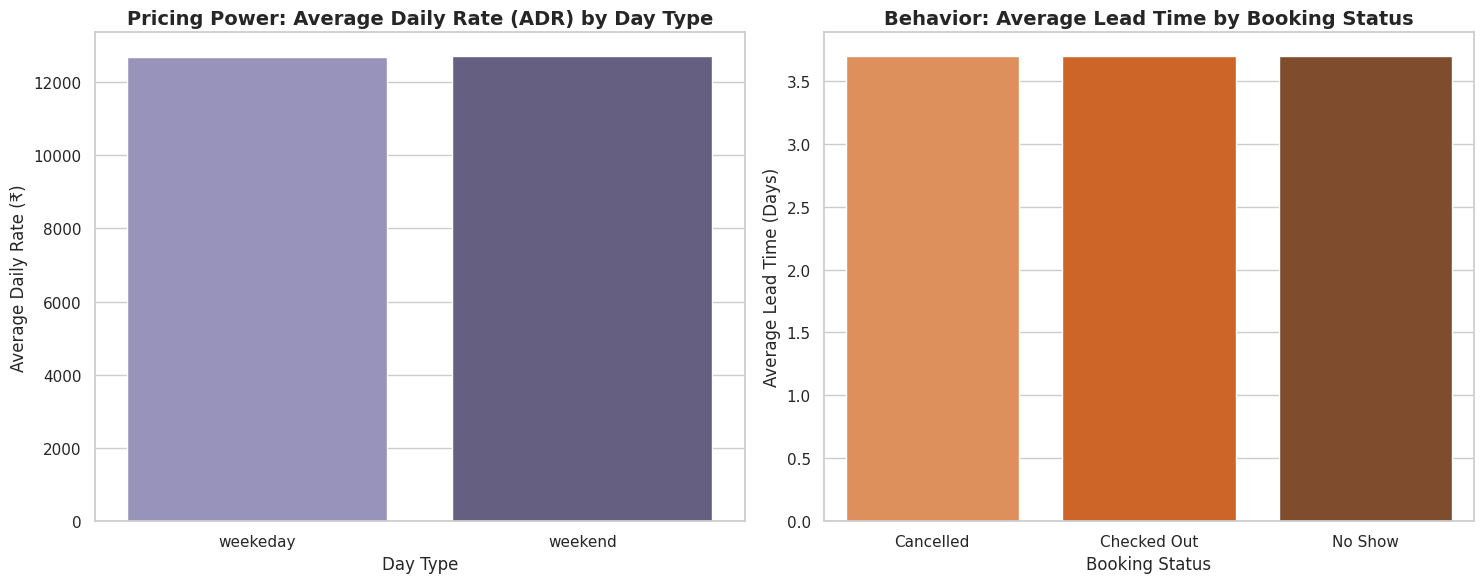

In [49]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Chart 1: Average Daily Rate by Day Type ---
sns.barplot(
    data=day_type_stats,
    x='day_type',
    y='average_daily_rate',
    ax=axes[0],
    palette='Purples_d'
)
axes[0].set_title('Pricing Power: Average Daily Rate (ADR) by Day Type', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day Type', fontsize=12)
axes[0].set_ylabel('Average Daily Rate (₹)', fontsize=12)

# --- Chart 2: Average Lead Time by Booking Status ---
sns.barplot(
    data=behavior_stats,
    x='booking_status',
    y='avg_lead_time_days',
    ax=axes[1],
    palette='Oranges_d'
)
axes[1].set_title('Behavior: Average Lead Time by Booking Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Booking Status', fontsize=12)
axes[1].set_ylabel('Average Lead Time (Days)', fontsize=12)

plt.tight_layout()

In [50]:
saving_plots(fig, "phase_3_behavior_report")

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_3_behavior_report.png


In [51]:
def saving_table_visual(df, file_name):
  fig, ax = plt.subplots(figsize=(10, 4))

  # Hide the standard graph axes
  ax.axis('tight')
  ax.axis('off')

  # Draw the table on the blank figure
  table = ax.table(
    cellText=platform_stats.values,
    colLabels=platform_stats.columns,
    loc='center',
    cellLoc='center'
  )

  # Make the rows a little taller for readability
  table.scale(1, 1.8)

  saving_plots(fig, file_name)

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_3_day_type_stats.png
Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_3_behavior_stats.png


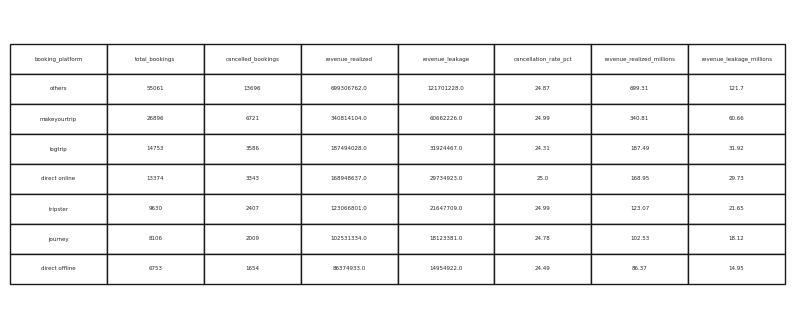

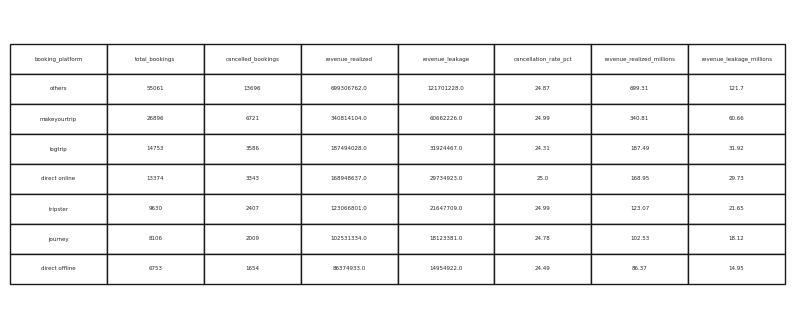

In [52]:
saving_table_visual(day_type_stats, "phase_3_day_type_stats")
saving_table_visual(behavior_stats, "phase_3_behavior_stats")

### Phase 3 conclusion:

These charts reveal a glaring lack of dynamic strategy: Atliq's Average Daily Rate (ADR) is completely flat across weekdays and weekends, meaning they are leaving easy money on the table by failing to implement weekend surge pricing. Furthermore, the average lead time is an identical ~3.7 days across all booking statuses, proving that our high cancellation rate isn't caused by long-term planners changing their minds, but rather by short-term booking flakiness that goes completely unpenalized.

### **Phase 4: Revenue Leakage Deep Dive**

This is where the rubber meets the road. High-level insights are great, but hotel managers need to know exactly which buildings are losing the most money so they can intervene. We are going to isolate the Top 5 individual properties that are bleeding the highest absolute amount of cash due to cancellations and no-shows.

In [53]:
# Group by property to calculate total revenue leakage
property_leakage = df_merged.groupby(['property_name', 'city']).agg(
    total_leakage = ('revenue_leakage', 'sum')
).reset_index()

# Convert to millions for clean reporting
property_leakage['leakage_in_millions'] = (property_leakage['total_leakage'] / 1000000).round(2)

# Sort descending and grab the Top 5 absolute worst offenders
top_5_bleeders = property_leakage.sort_values(by = 'leakage_in_millions', ascending = False).head(5)
top_5_bleeders['city_and_property'] = top_5_bleeders['city'] + ' - ' + top_5_bleeders['property_name']

In [54]:
print("--- The Top 5 Bleeding Properties ---")
display(top_5_bleeders[['property_name', 'city', 'leakage_in_millions']])

--- The Top 5 Bleeding Properties ---


,property_name,city,leakage_in_millions
14,Atliq Exotica,Mumbai,35.94
22,Atliq Palace,Mumbai,17.11
20,Atliq Palace,Delhi,16.06
11,Atliq City,Mumbai,15.78
8,Atliq City,Bangalore,15.61


### Visualizing the Target List

/tmp/ipykernel_79207/2970141706.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


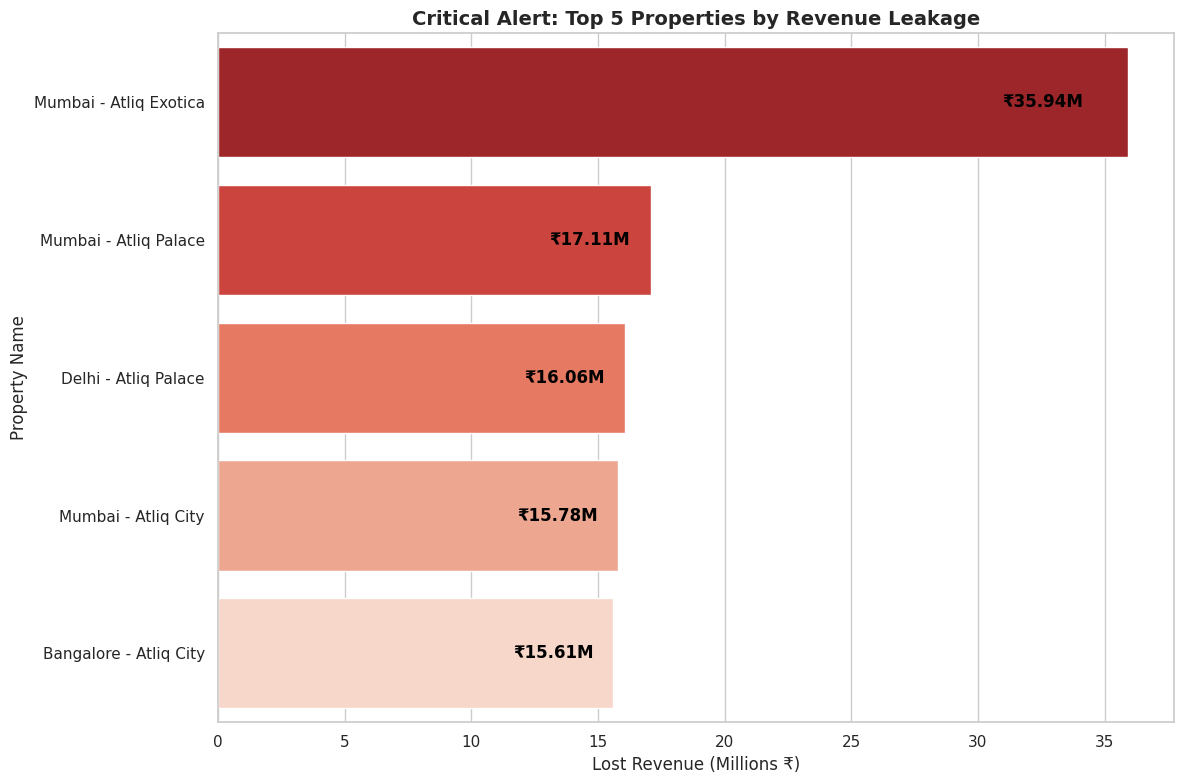

In [55]:
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(12, 8))

# --- Chart: Top 5 Properties by Leakage ---
# Using a deep red palette to emphasize financial loss
ax = sns.barplot(
    data=top_5_bleeders,
    x='leakage_in_millions',
    y='city_and_property',
    palette='Reds_r'
)

plt.title('Critical Alert: Top 5 Properties by Revenue Leakage', fontsize=14, fontweight='bold')
plt.xlabel('Lost Revenue (Millions ₹)', fontsize=12)
plt.ylabel('Property Name', fontsize=12)

# Add exact million labels inside the bars for instant readability
for index, value in enumerate(top_5_bleeders['leakage_in_millions']):
    plt.text(value - (value * 0.05), index, f'₹{value}M',
             color='black', ha='right', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [56]:
saving_plots(fig, "phase_4_report")

Plots saved successfully to: /content/drive/MyDrive/Codebasics/Projects/EDA in Hospitality Domain/Scripts/plots/phase_4_report.png


### Phase 4 conclusion:

The data reveals a severe concentration of revenue leakage in the Mumbai market, with Mumbai - Atliq Exotica alone bleeding a staggering ₹35.94M—more than double the next highest property on the list. Since three of our top five worst-performing properties are located in Mumbai, executive management needs to immediately investigate regional operations and deposit policies in that specific city to stop the bleeding.

### **Phase 5: Ad-Hoc Analysis**

These questions introduce entirely new dimensions—specifically, monthly time-series analysis and customer satisfaction (ratings).

The Phase 1 report has already covered Q1, Q2, Q6 and Q8 which are determining Occupancy by category, Average occupancy per city, Revenue realized per city and Revenue realized per hotel type/category repectively.

For Q10 (Pie chart for revenue per platform), mostly covered in Phase 2. We used a stacked bar chart (which is actually considered a better data science practice than a pie chart for comparing revenue).

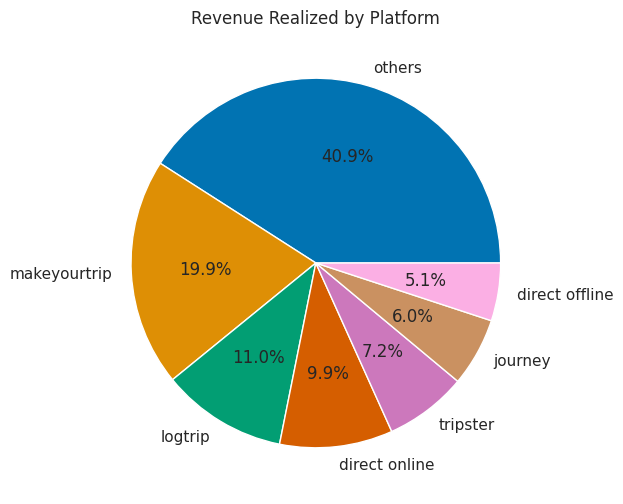

In [67]:
sns.set(style="whitegrid")

# Create a pie chart using Matplotlib but styled with Seaborn
plt.figure(figsize=(6,6))
plt.pie(
    platform_stats['revenue_realized_millions'],
    labels=platform_stats['booking_platform'],
    autopct='%1.1f%%',
    colors=sns.color_palette("colorblind")  # Seaborn color palette
)
plt.title("Revenue Realized by Platform")
plt.show()

For Q3 (Occupancy: Weekday vs Weekend), we partially covered this in Phase 3. We calculated the Average Daily Rate (ADR) by Day Type, but we didn't calculate the Occupancy by Day Type.

In [75]:
df = pd.merge(df_agg_merged, df_date, left_on="check_in_date", right_on="date")
display(df.groupby("day_type")["occ_pct"].mean().round(2))

,occ_pct
day_type,
weekeday,51.81
weekend,73.97


For Q4 (June occupancy in different cities), requires filtering the data by month before grouping by city.

In [78]:
df_june_22 = df[df["mmm yy"]=="Jun 22"]
df_june_22.groupby('city')['occ_pct'].mean().round(2).sort_values(ascending=False)

,occ_pct
city,
Delhi,61.46
Mumbai,57.79
Hyderabad,57.69
Bangalore,55.85


For Q7 (Month-by-month revenue), requires grouping revenue_realized by the month column.

In [79]:
df_merged.groupby("mmm yy")["revenue_realized"].sum()

,revenue_realized
mmm yy,
Aug-22,0.0
Jul 22,572843348.0
Jun 22,553925855.0
May 22,581767396.0


For Q9 (Average rating per city), requires analyzing the ratings_given column (which we deliberately preserved in the Data Cleaning phase) and grouping it by city.

In [80]:
df_merged.groupby('city')['ratings_given'].mean().round(2)

,ratings_given
city,
Bangalore,3.41
Delhi,3.78
Hyderabad,3.66
Mumbai,3.65


For Q5 (Append August data), this is not an EDA question; this is a foundational Data Engineering task. You must do this before you run any of your Phase 1-5 reports.